### Reinforcement Learning para Trading Algorítmico (Concepto)

El Reinforcement Learning (RL) implica entrenar a un 'agente' para que tome decisiones (acciones) en un 'entorno' (el mercado financiero) con el objetivo de maximizar una 'recompensa' (beneficios).

**Componentes clave:**
-   **Entorno:** El mercado, representado por datos históricos de precios.
-   **Agente:** El modelo de RL que toma decisiones (comprar, vender, mantener).
-   **Estado:** La información disponible para el agente en un momento dado (precios, indicadores técnicos, volumen).
-   **Acción:** Las decisiones que el agente puede tomar (por ejemplo, `0` = mantener, `1` = comprar, `2` = vender).
-   **Recompensa:** La retroalimentación positiva o negativa que recibe el agente por sus acciones (por ejemplo, el beneficio o la pérdida de una operación).

Vamos a empezar por la parte de la adquisición de datos y la preparación de características.

In [14]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Definir el símbolo del activo y el rango de fechas
# Ejemplo: Apple Inc.
SYMBOL = 'AAPL'
START_DATE = '2020-01-01'
END_DATE = '2023-01-01'

# Descargar datos históricos de Yahoo Finance
# Explicitly set auto_adjust=True for simpler column structure
df = yf.download(SYMBOL, start=START_DATE, end=END_DATE, auto_adjust=True)

print(f"Datos históricos para {SYMBOL} de {START_DATE} a {END_DATE}:")
display(df.head())
print(f"Initial DataFrame shape: {df.shape}")
print(f"Initial DataFrame columns: {df.columns}")
print("Initial DataFrame info:")
df.info()
print("Initial DataFrame describe:")
display(df.describe())

[*********************100%***********************]  1 of 1 completed

Datos históricos para AAPL de 2020-01-01 a 2023-01-01:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400
2020-01-03,71.630661,72.389280,71.406689,71.563228,146322800
2020-01-06,72.201424,72.239958,70.503561,70.754028,118387200
2020-01-07,71.861847,72.466330,71.642689,72.211049,108872000
2020-01-08,73.017830,73.318870,71.565614,71.565614,132079200


Initial DataFrame shape: (756, 5)
Initial DataFrame columns: MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])
Initial DataFrame info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 756 entries, 2020-01-02 to 2022-12-30
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   756 non-null    float64
 1   (High, AAPL)    756 non-null    float64
 2   (Low, AAPL)     756 non-null    float64
 3   (Open, AAPL)    756 non-null    float64
 4   (Volume, AAPL)  756 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 35.4 KB
Initial DataFrame describe:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,756.000000,756.000000,756.000000,756.000000,7.560000e+02
mean,127.128755,128.671053,125.473652,127.051113,1.120920e+08
std,30.301251,30.577591,30.020452,30.329240,5.602586e+07
min,54.163700,55.160698,51.324796,55.059309,3.519590e+07
25%,112.264149,113.753648,110.812214,112.443597,7.636470e+07
50%,132.485184,133.613784,130.532813,132.307426,9.493580e+07
75%,147.635815,148.798288,145.698860,147.005595,1.296327e+08
max,177.939713,178.848915,175.114335,178.545850,4.265100e+08


### Ingeniería de Características (Ejemplo Simplificado)

Para el RL, el 'estado' que se le presenta al agente debe contener información relevante para la toma de decisiones. Esto a menudo implica crear indicadores técnicos a partir de los precios históricos.

Aquí tienes algunos ejemplos básicos de características que se podrían usar:
-   **Retornos Diarios:** El cambio porcentual en el precio de cierre.
-   **Medias Móviles (SMA):** Promedios de precios durante un período específico para identificar tendencias.
-   **Volatilidad:** Medida de la variación del precio.

Para un sistema de RL más avanzado, se considerarían muchos más indicadores, así como datos fundamentales o de sentimiento.

Shape before processing columns: (756, 5)
Columns before processing: MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])
DataFrame columns flattened to single level.
Columns after flattening: Index(['Close_AAPL', 'High_AAPL', 'Low_AAPL', 'Open_AAPL', 'Volume_AAPL'], dtype='object')
Identified and renamed 'Close_AAPL' to 'Close_Price'.
Shape after initial column processing: (756, 5)
Columns after initial column processing: Index(['Close_Price', 'High_AAPL', 'Low_AAPL', 'Open_AAPL', 'Volume_AAPL'], dtype='object')
Number of NaNs in 'Close_Price' before feature calculation: 0
Shape after feature calculation: (756, 9)
Columns after feature calculation: Index(['Close_Price', 'High_AAPL', 'Low_AAPL', 'Open_AAPL', 'Volume_AAPL',
       'Daily_Return', 'SMA_10', 'SMA_30', 'Volatility_10'],
      dtype='object')
NaNs after feature calculation:
Close_

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Close_Price,High_AAPL,Low_AAPL,Open_AAPL,Volume_AAPL,Daily_Return,SMA_10,SMA_30,Volatility_10
Date,,,,,,,,,
2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400,NaN,NaN,NaN,NaN
2020-01-03,71.630661,72.389280,71.406689,71.563228,146322800,-0.009722,NaN,NaN,NaN
2020-01-06,72.201424,72.239958,70.503561,70.754028,118387200,0.007968,NaN,NaN,NaN
2020-01-07,71.861847,72.466330,71.642689,72.211049,108872000,-0.004703,NaN,NaN,NaN
2020-01-08,73.017830,73.318870,71.565614,71.565614,132079200,0.016086,NaN,NaN,NaN
2020-01-09,74.568787,74.761449,73.742735,73.993195,170108400,0.021241,NaN,NaN,NaN
2020-01-10,74.737381,75.300934,74.236454,74.802410,140644800,0.002261,NaN,NaN,NaN
2020-01-13,76.334091,76.360587,74.934858,75.052871,121532000,0.021364,NaN,NaN,NaN
2020-01-14,75.303322,76.480993,75.180503,76.271471,161954400,-0.013503,NaN,NaN,NaN


Shape after filtering columns: (756, 5)
Columns after filtering columns: Index(['Close_Price', 'Daily_Return', 'SMA_10', 'SMA_30', 'Volatility_10'], dtype='object')
Final DataFrame shape after dropna: (727, 5)
DataFrame con características añadidas y columnas simplificadas:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Close_Price,Daily_Return,SMA_10,SMA_30,Volatility_10
Date,,,,,
2020-02-13,78.424774,-0.007121,77.084743,75.793819,0.021394
2020-02-14,78.444069,0.000246,77.475160,75.997492,0.014482
2020-02-18,77.007729,-0.018310,77.742414,76.176728,0.016170
2020-02-19,78.123024,0.014483,77.875790,76.374114,0.013226
2020-02-20,77.321541,-0.010259,77.866399,76.556104,0.013522


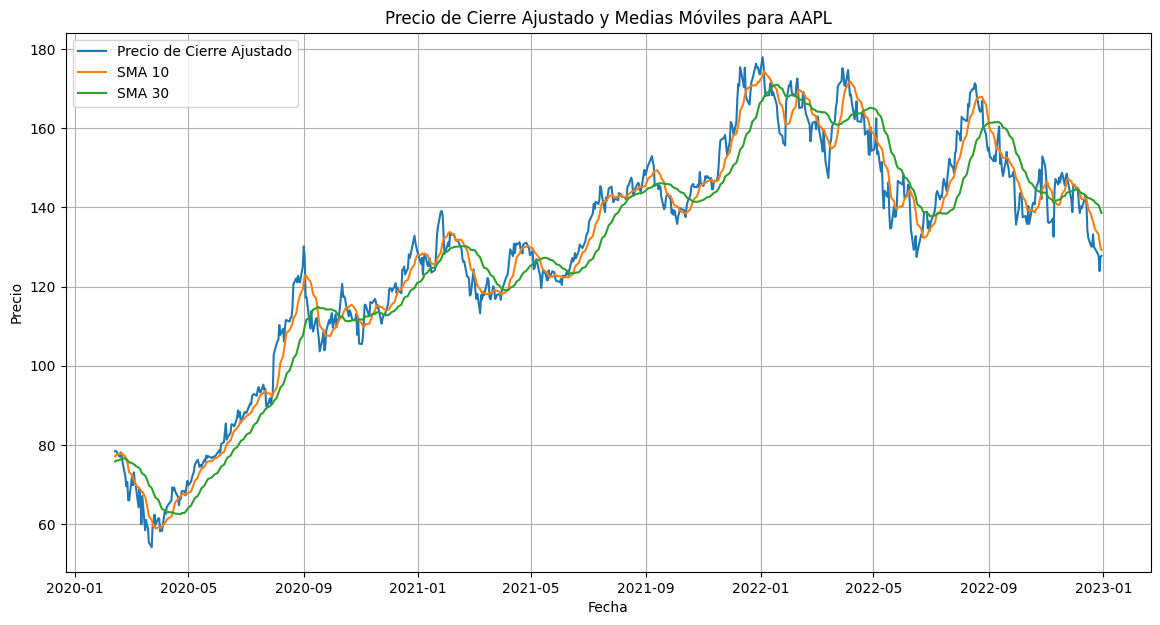

In [15]:
# Ensure a consistent 'Close_Price' column and flatten MultiIndex if present

# Step 0: Make a copy to avoid SettingWithCopyWarning
df_copy = df.copy()

print(f"Shape before processing columns: {df_copy.shape}")
print(f"Columns before processing: {df_copy.columns}")

# Robust MultiIndex flattening
if isinstance(df_copy.columns, pd.MultiIndex):
    # Flatten MultiIndex to a single level, joining elements with '_' if necessary
    new_columns = []
    for col_pair in df_copy.columns.values:
        if isinstance(col_pair, tuple):
            # Join non-empty parts of the tuple. e.g. ('Close', 'AAPL') -> 'Close_AAPL', ('Volume', '') -> 'Volume'
            cleaned_parts = [part for part in col_pair if part] # Filter out empty strings
            # If the tuple is just ('Close',) for some reason, use 'Close'. If ('Close', 'AAPL'), use 'Close_AAPL'.
            new_columns.append('_'.join(cleaned_parts) if cleaned_parts else col_pair[0])
        else:
            new_columns.append(str(col_pair)) # Already single level
    df_copy.columns = new_columns
    print("DataFrame columns flattened to single level.")
    print(f"Columns after flattening: {df_copy.columns}")
else:
    print("DataFrame columns are already single level.")
    print(f"Columns: {df_copy.columns}")

# Step 2: Identify and rename the primary closing price column to 'Close_Price'
found_close_col_name = None
# Prioritize 'Adj Close' (if it appears after auto_adjust=True or from old yf versions)
# Then 'Close' (if auto_adjust=True), then flattened forms
possible_close_names = ['Adj Close', 'Close', f'Close_{SYMBOL}', f'Adj Close_{SYMBOL}', 'Price_Close']

for name in possible_close_names:
    if name in df_copy.columns:
        found_close_col_name = name
        break

if found_close_col_name:
    if found_close_col_name != 'Close_Price': # Only rename if necessary
        df_copy.rename(columns={found_close_col_name: 'Close_Price'}, inplace=True)
    print(f"Identified and renamed '{found_close_col_name}' to 'Close_Price'.")
else:
    raise KeyError(f"Could not find a suitable 'Adj Close' or 'Close' column in the DataFrame. Columns found: {df_copy.columns.tolist()}")

# Ensure 'Close_Price' exists before proceeding
if 'Close_Price' not in df_copy.columns:
    raise KeyError("The 'Close_Price' column is missing after renaming. This should not happen if previous logic worked.")

# Explicitly convert 'Close_Price' to numeric, coercing errors
df_copy['Close_Price'] = pd.to_numeric(df_copy['Close_Price'], errors='coerce')
if df_copy['Close_Price'].isnull().all():
    raise ValueError("All values in 'Close_Price' are NaN after numeric conversion. Check raw data.")

print(f"Shape after initial column processing: {df_copy.shape}")
print(f"Columns after initial column processing: {df_copy.columns}")
print(f"Number of NaNs in 'Close_Price' before feature calculation: {df_copy['Close_Price'].isnull().sum()}")


# Step 3: Calculate features on df_copy
df_copy['Daily_Return'] = df_copy['Close_Price'].pct_change()
df_copy['SMA_10'] = df_copy['Close_Price'].rolling(window=10).mean()
df_copy['SMA_30'] = df_copy['Close_Price'].rolling(window=30).mean()
df_copy['Volatility_10'] = df_copy['Daily_Return'].rolling(window=10).std()

print(f"Shape after feature calculation: {df_copy.shape}")
print(f"Columns after feature calculation: {df_copy.columns}")
print(f"NaNs after feature calculation:\n{df_copy.isnull().sum()}")
display(df_copy.head(35)) # Check initial NaNs


# Step 4: Filter relevant columns
feature_cols_to_keep = ['Close_Price', 'Daily_Return', 'SMA_10', 'SMA_30', 'Volatility_10']
# Ensure all feature_cols_to_keep exist in df_copy.columns before filtering
existing_feature_cols = [col for col in feature_cols_to_keep if col in df_copy.columns]

if len(existing_feature_cols) != len(feature_cols_to_keep):
    missing_cols = set(feature_cols_to_keep) - set(existing_feature_cols)
    raise KeyError(f"Missing required feature columns: {missing_cols}. Current columns: {df_copy.columns.tolist()}")

df_final = df_copy[feature_cols_to_keep].copy() # Create a clean final DataFrame


print(f"Shape after filtering columns: {df_final.shape}")
print(f"Columns after filtering columns: {df_final.columns}")

# Step 5: Drop rows with NaN values
df_final.dropna(inplace=True)

# Add a check here for empty dataframe
if df_final.empty:
    raise ValueError("DataFrame is empty after feature engineering and dropping NaNs. This indicates an issue with the data or window sizes.")

df = df_final # Assign the processed DataFrame back to the global df

print(f"Final DataFrame shape after dropna: {df.shape}")
print("DataFrame con características añadidas y columnas simplificadas:")
display(df.head())

# Visualizar algunos de los indicadores
plt.figure(figsize=(14, 7))
plt.plot(df['Close_Price'], label='Precio de Cierre Ajustado') # Usar la nueva columna 'Close_Price'
plt.plot(df['SMA_10'], label='SMA 10')
plt.plot(df['SMA_30'], label='SMA 30')
plt.title(f'Precio de Cierre Ajustado y Medias Móviles para {SYMBOL}')
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.legend()
plt.grid(True)
plt.show()

### Estructura Conceptual del Entorno de Reinforcement Learning

Aquí es donde la implementación se vuelve más compleja. Un entorno de RL generalmente se construye utilizando la interfaz `gym` (OpenAI Gym), que define los métodos `reset()` y `step()`.

**`reset()`:** Reinicia el entorno y devuelve el estado inicial.
**`step(action)`:** Ejecuta una acción en el entorno, calcula la nueva recompensa y el siguiente estado, y determina si el episodio ha terminado.

#### Cómo se vería en el trading:

1.  **Definir el `Estado`:** Un vector que contiene las características que creamos (retornos diarios, SMAs, volatilidad, etc.).
2.  **Definir las `Acciones`:**
    *   `0`: Mantener (no hacer nada).
    *   `1`: Comprar (abrir una posición larga o añadir a una existente).
    *   `2`: Vender (cerrar una posición o abrir una posición corta si se permite).
3.  **Definir la `Recompensa`:** Podría ser el cambio en el valor de la cartera o la ganancia/pérdida de la última operación.
4.  **Lógica del `step`:**
    *   Recibe una acción del agente.
    *   Calcula el nuevo precio del activo.
    *   Simula el efecto de la acción (por ejemplo, si se compra, se reduce el efectivo y se aumenta la posición de stock).
    *   Calcula la recompensa basada en el cambio en el valor de la cartera.
    *   Genera el nuevo estado a partir de las características actualizadas.
    *   Comprueba si el episodio ha terminado (por ejemplo, se ha agotado el capital o se ha alcanzado el final de los datos).

#### Implementación de un Agente (con `stable_baselines3`)

Una vez que tengas tu entorno `gym` definido, puedes usar bibliotecas como `stable_baselines3` para implementar y entrenar agentes de RL como PPO, A2C, DQN, etc.

```python
# Esto es solo un ejemplo conceptual, no código ejecutable completo.

# from stable_baselines3 import PPO
# from stable_baselines3.common.env_util import make_vec_env
# import gym

# class StockTradingEnv(gym.Env):
#     def __init__(self, df):
#         super(StockTradingEnv, self).__init__()
#         self.df = df
#         self.current_step = 0
#         # Definir espacios de acción y observación
#         self.action_space = gym.spaces.Discrete(3) # Buy, Sell, Hold
#         self.observation_space = gym.spaces.Box(low=-np.inf, high=np.inf, shape=(df.shape[1],), dtype=np.float32)
#         # Inicializar cartera (ejemplo)
#         self.balance = 100000
#         self.stock_held = 0

#     def _get_obs(self):
#         # Devolver el estado actual (características de la fila actual del DataFrame)
#         return self.df.iloc[self.current_step].values.astype(np.float32)

#     def _get_reward(self):
#         # Calcular recompensa (ej. cambio en el valor de la cartera)
#         current_value = self.balance + self.stock_held * self.df['Adj Close'].iloc[self.current_step]
#         previous_value = self.balance + self.stock_held * self.df['Adj Close'].iloc[self.current_step - 1]
#         return current_value - previous_value

#     def reset(self):
#         self.current_step = 0
#         self.balance = 100000
#         self.stock_held = 0
#         return self._get_obs()

#     def step(self, action):
#         self.current_step += 1
#         if self.current_step >= len(self.df) - 1:
#             done = True
#         else:
#             done = False

#         reward = 0
#         current_price = self.df['Adj Close'].iloc[self.current_step]

#         if action == 1: # Comprar
#             # Lógica de compra (ej. comprar una cantidad fija o todo el efectivo disponible)
#             buy_amount = self.balance / current_price # Comprar con todo el capital disponible
#             self.stock_held += buy_amount
#             self.balance = 0
#         elif action == 2: # Vender
#             # Lógica de venta (ej. vender todas las acciones)
#             self.balance += self.stock_held * current_price
#             self.stock_held = 0

#         reward = self._get_reward() # Calcular recompensa después de la acción

#         return self._get_obs(), reward, done, {}

# # Crear el entorno
# env = StockTradingEnv(df)

# # Entrenar un agente PPO (ejemplo)
# # model = PPO('MlpPolicy', env, verbose=1)
# # model.learn(total_timesteps=10000)

# # Una vez entrenado, puedes usar el agente para operar
# # obs = env.reset()
# # for i in range(len(df) - 1):
# #     action, _states = model.predict(obs, deterministic=True)
# #     obs, reward, done, info = env.step(action)
# #     if done:
# #         break
```

La implementación completa de un entorno de trading de RL y un agente requiere un conocimiento profundo de RL, simulación de trading y gestión de riesgos. Este es un punto de partida para que puedas explorar más a fondo.

### 1. Instalación de Bibliotecas Necesarias

Necesitamos instalar `gym` para crear el entorno de RL y `stable_baselines3` para implementar y entrenar el agente.

In [9]:
!pip install gym stable-baselines3 pandas numpy matplotlib shimmy

### 2. Creación del Entorno de Trading (OpenAI Gym)

Ahora, implementaremos el entorno de trading como una clase `StockTradingEnv` que hereda de `gym.Env`. Este entorno simulará las interacciones de un agente con el mercado, recibiendo estados, procesando acciones y devolviendo recompensas.

In [13]:
import gym
from gym import spaces

class StockTradingEnv(gym.Env):
    """Un entorno de trading de acciones básico para RL usando OpenAI Gym."""

    metadata = {'render_modes': ['human'], 'render_fps': 30}

    def __init__(self, df, initial_balance=10000, lookback_window_size=10):
        super(StockTradingEnv, self).__init__()
        self.df = df.copy()
        self.initial_balance = initial_balance
        self.balance = initial_balance
        self.shares_held = 0
        self.net_worth = initial_balance
        self.max_net_worth = initial_balance
        self.lookback_window_size = lookback_window_size
        self.current_step = lookback_window_size # Empezar después de la ventana de lookback

        # Definir el espacio de acciones:
        # 0: Mantener (Hold)
        # 1: Comprar (Buy)
        # 2: Vender (Sell)
        self.action_space = spaces.Discrete(3)

        # Definir el espacio de observación (estado):
        # Incluirá el balance, acciones en cartera, valor neto y las últimas 'lookback_window_size' filas
        # de características del DataFrame (Precio de Cierre, Retornos Diarios, SMAs, Volatilidad).

        # Ajustar el shape del observation_space
        # El estado incluirá: [balance, acciones_en_cartera, valor_neto, historial_de_características_recientes]
        # El historial de características recientes será (lookback_window_size * número_de_features_por_dia)

        # Las características relevantes del DataFrame serán las columnas que hemos calculado más el precio de cierre
        # Asegurarse de que las columnas usadas en el estado son numéricas.
        # Hemos simplificado las columnas del DataFrame para que 'Close_Price' sea un nombre de columna simple.
        self.features_columns = ['Close_Price', 'Daily_Return', 'SMA_10', 'SMA_30', 'Volatility_10']

        # Verificar que las columnas existen en el df después del dropna
        for col in self.features_columns:
            if col not in self.df.columns:
                raise ValueError(f"La columna '{col}' no se encuentra en el DataFrame. Asegúrese de que el procesamiento de características se ha ejecutado correctamente.")

        low = -np.inf
        high = np.inf

        # El estado es un array 1D de flotantes
        # balance, shares_held, net_worth + características del lookback window
        num_features_per_day = len(self.features_columns)
        self.observation_space = spaces.Box(low=low, high=high, shape=(3 + self.lookback_window_size * num_features_per_day,), dtype=np.float32)

    def _get_obs(self):
        """Genera el estado actual del entorno."""
        # Obtener las características de la ventana de lookback
        end_idx = self.current_step
        start_idx = self.current_step - self.lookback_window_size

        # Asegurarse de que las características sean numéricas y sin NaNs
        # Manejar posibles NaNs de nuevo si por alguna razón aparecen después del dropna inicial
        state_features = self.df[self.features_columns].iloc[start_idx:end_idx].values.flatten() # Acceso con nombres de columna simples

        # Concatenar información de la cartera con las características del mercado
        observation = np.array([self.balance, self.shares_held, self.net_worth] + state_features.tolist(), dtype=np.float32)
        return observation

    def _calculate_portfolio_value(self, current_price):
        return self.balance + self.shares_held * current_price

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.balance = self.initial_balance
        self.shares_held = 0
        self.net_worth = self.initial_balance
        self.max_net_worth = self.initial_balance
        self.current_step = self.lookback_window_size # Reiniciar el paso actual

        # Asegurarse de que el DataFrame tiene suficientes datos para el lookback_window_size
        if len(self.df) <= self.lookback_window_size:
            raise ValueError("DataFrame no tiene suficientes datos para el lookback_window_size")

        observation = self._get_obs()
        info = {"balance": self.balance, "shares_held": self.shares_held, "net_worth": self.net_worth}
        return observation, info

    def step(self, action):
        self.current_step += 1

        # Determinar si el episodio ha terminado
        done = self.current_step >= len(self.df) - 1

        # Obtener el precio actual (ahora usando el nombre de columna simple 'Close_Price')
        current_price = self.df['Close_Price'].iloc[self.current_step] if self.current_step < len(self.df) else self.df['Close_Price'].iloc[-1]

        # Lógica de recompensa inicial
        # Recompensa = cambio en el valor neto de la cartera
        prev_net_worth = self.net_worth
        self.net_worth = self._calculate_portfolio_value(current_price)
        reward = self.net_worth - prev_net_worth

        # Ejecutar la acción
        if action == 1:  # Comprar
            # Comprar con todo el capital disponible (simplificado)
            if self.balance > 0 and current_price > 0:
                shares_to_buy = self.balance // current_price # Comprar acciones enteras
                self.shares_held += shares_to_buy
                self.balance -= shares_to_buy * current_price
                # print(f"Bought {shares_to_buy} shares at {current_price:.2f}")
        elif action == 2:  # Vender
            # Vender todas las acciones (simplificado)
            if self.shares_held > 0 and current_price > 0:
                self.balance += self.shares_held * current_price
                # print(f"Sold {self.shares_held} shares at {current_price:.2f}")
                self.shares_held = 0

        # Actualizar el valor neto después de la acción
        self.net_worth = self._calculate_portfolio_value(current_price)

        # Penalización por perder todo el dinero, si aplica.
        # if self.net_worth <= 0: # O un umbral bajo
        #     done = True
        #     reward = -100 # Gran penalización

        # Recompensa por valor neto creciente
        if self.net_worth > self.max_net_worth:
            self.max_net_worth = self.net_worth

        # El estado del observation space debe ser un array 1D de flotantes
        # Asegurarse de que self._get_obs() maneje correctamente los límites al final del DataFrame
        observation = self._get_obs() if not done else self._get_obs() # Se mantiene el último estado si done

        info = {"balance": self.balance, "shares_held": self.shares_held, "net_worth": self.net_worth}
        return observation, reward, done, False, info # Gym API cambió a devolver 5 elementos (obs, reward, terminated, truncated, info)

### 3. Entrenamiento del Agente RL con `stable_baselines3`

Una vez que tenemos el entorno definido, podemos usar `stable_baselines3` para entrenar un agente. Utilizaremos el algoritmo PPO (Proximal Policy Optimization) por su buen rendimiento y estabilidad en una variedad de tareas.

In [16]:
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.evaluation import evaluate_policy

# Crear una instancia del entorno
env = StockTradingEnv(df)

# Stable Baselines3 requiere que el entorno sea 'vectorizado'
# DummyVecEnv es una forma simple de hacerlo para un solo entorno.
vec_env = DummyVecEnv([lambda: env])

# Crear un modelo PPO
# "MlpPolicy" significa que usaremos una red neuronal tipo Perceptrón Multicapa como política.
model = PPO("MlpPolicy", vec_env, verbose=1, tensorboard_log="./ppo_stock_trading_tensorboard/")

print("Comenzando el entrenamiento del agente PPO...")
# Entrenar el agente por un número de "timesteps" (interacciones con el entorno)
model.learn(total_timesteps=100000) # Ajusta este número para un entrenamiento más largo o más corto

print("Entrenamiento completado. Evaluando el agente...")

# Evaluar la política del agente entrenado
mean_reward, std_reward = evaluate_policy(model, vec_env, n_eval_episodes=10)

print(f"Recompensa media: {mean_reward:.2f} +/- {std_reward:.2f}")

print("Puedes visualizar el progreso del entrenamiento con TensorBoard ejecutando:")
print("tensorboard --logdir ./ppo_stock_trading_tensorboard/")


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Using cpu device
Comenzando el entrenamiento del agente PPO...
Logging to ./ppo_stock_trading_tensorboard/PPO_1


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

-----------------------------
| time/              |      |
|    fps             | 1149 |
|    iterations      | 1    |
|    time_elapsed    | 1    |
|    total_timesteps | 2048 |
-----------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Entrenamiento completado. Evaluando el agente...


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Recompensa media: 0.00 +/- 0.00
Puedes visualizar el progreso del entrenamiento con TensorBoard ejecutando:
tensorboard --logdir ./ppo_stock_trading_tensorboard/


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### 4. Simulación y Visualización del Rendimiento del Agente

Para fines pedagógicos, es útil ver cómo se comporta el agente después del entrenamiento. Podemos ejecutar el entorno en modo de inferencia y visualizar los resultados.

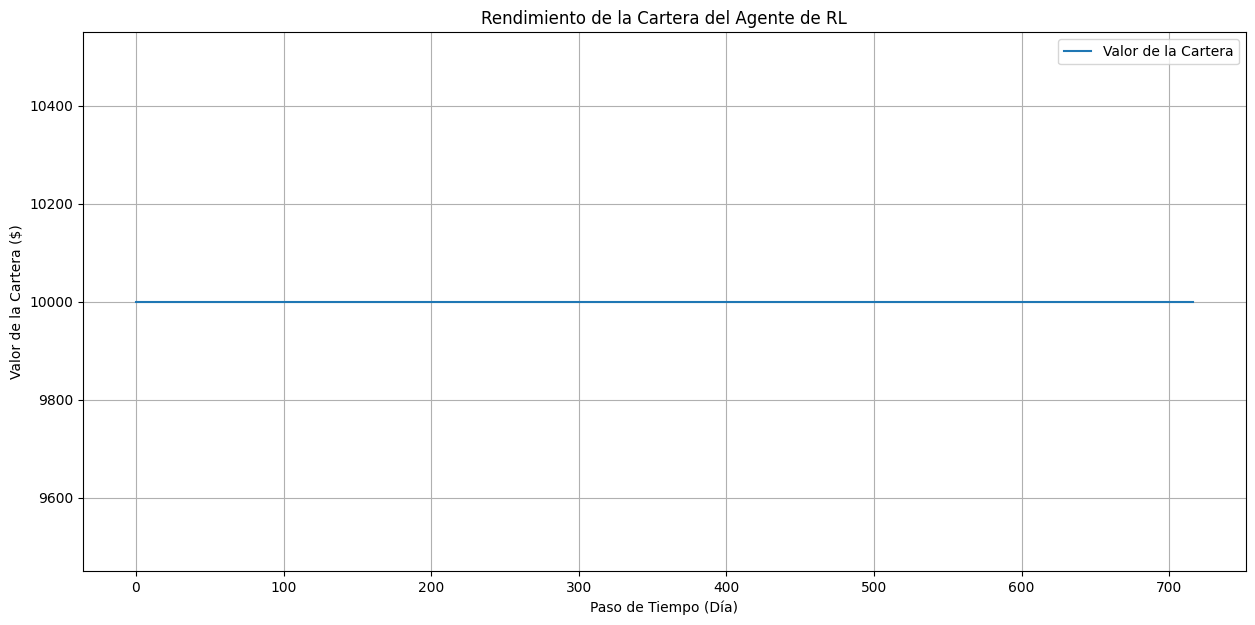

Valor final de la cartera: 10000.00 $
Balance final: 10000.00 $
Acciones finales en cartera: 0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [17]:
# Reiniciar el entorno para una nueva simulación
obs, info = env.reset()

# Listas para almacenar el historial de la simulación
portfolio_values = [env.initial_balance]
balances = [env.initial_balance]
shares_held = [0]

# Ejecutar el agente en el entorno
for i in range(len(env.df) - env.lookback_window_size -1):
    action, _states = model.predict(obs, deterministic=True) # deterministic=True para acciones consistentes
    obs, reward, terminated, truncated, info = env.step(action)

    portfolio_values.append(info['net_worth'])
    balances.append(info['balance'])
    shares_held.append(info['shares_held'])

    if terminated or truncated:
        break

# Visualizar el rendimiento de la cartera
plt.figure(figsize=(15, 7))
plt.plot(portfolio_values, label='Valor de la Cartera')
plt.title('Rendimiento de la Cartera del Agente de RL')
plt.xlabel('Paso de Tiempo (Día)')
plt.ylabel('Valor de la Cartera ($)')
plt.legend()
plt.grid(True)
plt.show()

print(f"Valor final de la cartera: {portfolio_values[-1]:.2f} $")
print(f"Balance final: {balances[-1]:.2f} $")
print(f"Acciones finales en cartera: {shares_held[-1]}")
